In [1]:
!pip -q install transformers sentencepiece sacrebleu accelerate psutil pandas matplotlib tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.4 MB/s eta 0:00:00


In [2]:
import time
import psutil
import pandas as pd
import matplotlib.pyplot as plt

from transformers import (
    MarianMTModel,
    MarianTokenizer,
    M2M100ForConditionalGeneration,
    M2M100Tokenizer
)

from sacrebleu import corpus_bleu

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Running on:", device)

Running on: cuda


In [3]:
print("Loading MarianMT...")

marian_model_name = "Helsinki-NLP/opus-mt-en-fr"

marian_tokenizer = MarianTokenizer.from_pretrained(
    marian_model_name
)

marian_model = MarianMTModel.from_pretrained(
    marian_model_name
).to(device)

print("MarianMT Loaded")


print("Loading M2M100...")

m2m_model_name = "facebook/m2m100_418M"

m2m_tokenizer = M2M100Tokenizer.from_pretrained(
    m2m_model_name
)

m2m_model = M2M100ForConditionalGeneration.from_pretrained(
    m2m_model_name
).to(device)

print("M2M100 Loaded")

Loading MarianMT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

M2M100 Loaded


In [4]:
LANGUAGES = {
    "en": "English",
    "fr": "French",
    "de": "German",
    "es": "Spanish",
    "hi": "Hindi"
}

print(LANGUAGES)

{'en': 'English', 'fr': 'French', 'de': 'German', 'es': 'Spanish', 'hi': 'Hindi'}


In [5]:
MAX_INPUT_LENGTH = 1000

def validate_input(text, src, tgt):

    if len(text.strip()) == 0:
        raise ValueError("Input text cannot be empty")

    if len(text) > MAX_INPUT_LENGTH:
        raise ValueError("Input text too long")

    if src not in LANGUAGES:
        raise ValueError("Invalid source language")

    if tgt not in LANGUAGES:
        raise ValueError("Invalid target language")

    if src == tgt:
        raise ValueError("Source and target languages must differ")

In [6]:
def translate_marian(
    text,
    max_length=128,
    num_beams=4,
    length_penalty=1.0,
    temperature=1.0,
    top_k=50,
    top_p=0.95
):

    inputs = marian_tokenizer(
        text,
        return_tensors="pt",
        truncation=True
    ).to(device)

    output = marian_model.generate(
        **inputs,
        max_length=max_length,
        num_beams=num_beams,
        length_penalty=length_penalty,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=(temperature != 1.0)
    )

    return marian_tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

In [7]:
def translate_m2m(
    text,
    src_lang,
    tgt_lang,
    max_length=128,
    num_beams=4,
    length_penalty=1.0,
    temperature=1.0,
    top_k=50,
    top_p=0.95
):

    m2m_tokenizer.src_lang = src_lang

    encoded = m2m_tokenizer(
        text,
        return_tensors="pt"
    ).to(device)

    generated = m2m_model.generate(
        **encoded,
        forced_bos_token_id=
        m2m_tokenizer.get_lang_id(tgt_lang),
        max_length=max_length,
        num_beams=num_beams,
        length_penalty=length_penalty,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=(temperature != 1.0)
    )

    return m2m_tokenizer.batch_decode(
        generated,
        skip_special_tokens=True
    )[0]

In [9]:
# ==================================================
# USER INPUT
# ==================================================

source_text = input(
    "Enter text to translate: "
)

source_lang = input(
    "Source language (en/fr/de/es/hi): "
).strip()

target_lang = input(
    "Target language (en/fr/de/es/hi): "
).strip()

# ==================================================
# VALIDATE INPUT
# ==================================================

validate_input(
    source_text,
    source_lang,
    target_lang
)

# ==================================================
# TRANSLATION PARAMETERS
# ==================================================

print("\n===== Translation Parameters =====")

max_length = int(
    input(
        "Maximum Output Length (e.g. 128): "
    )
)

num_beams = int(
    input(
        "Beam Search Width (e.g. 4): "
    )
)

length_penalty = float(
    input(
        "Length Penalty (e.g. 1.0): "
    )
)

temperature = float(
    input(
        "Temperature (e.g. 1.0): "
    )
)

top_k = int(
    input(
        "Top-k Sampling (e.g. 50): "
    )
)

top_p = float(
    input(
        "Top-p Sampling (e.g. 0.95): "
    )
)

# ==================================================
# MARIAN MT TRANSLATION
# ==================================================

print("\n=================================")
print("MarianMT Translation")
print("=================================\n")

try:

    marian_result = translate_marian(
        source_text,
        max_length=max_length,
        num_beams=num_beams,
        length_penalty=length_penalty,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p
    )

    print(marian_result)

except Exception:

    print(
        "Language pair not supported "
        "by MarianMT model."
    )

# ==================================================
# M2M100 TRANSLATION
# ==================================================

print("\n=================================")
print("M2M100 Translation")
print("=================================\n")

m2m_result = translate_m2m(
    source_text,
    source_lang,
    target_lang,
    max_length=max_length,
    num_beams=num_beams,
    length_penalty=length_penalty,
    temperature=temperature,
    top_k=top_k,
    top_p=top_p
)

print(m2m_result)

Enter text to translate: I am a student of computer science branch
Source language (en/fr/de/es/hi): en
Target language (en/fr/de/es/hi): fr

===== Translation Parameters =====
Maximum Output Length (e.g. 128): 128
Beam Search Width (e.g. 4): 4
Length Penalty (e.g. 1.0): 1.0
Temperature (e.g. 1.0): 1.0
Top-k Sampling (e.g. 50): 50
Top-p Sampling (e.g. 0.95): 0.95


[transformers] The following generation flags are not valid and may be ignored: ['top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



MarianMT Translation

Je suis étudiant en informatique.

M2M100 Translation

Je suis étudiant en informatique


In [10]:
def benchmark_model(
    model_name,
    function_call
):

    memory_before = psutil.Process().memory_info().rss

    cpu_before = psutil.cpu_percent()

    if torch.cuda.is_available():
        gpu_before = (
            torch.cuda.memory_allocated()
            /1024/1024
        )
    else:
        gpu_before = 0

    start = time.time()

    result = function_call()

    end = time.time()

    memory_after = psutil.Process().memory_info().rss

    cpu_after = psutil.cpu_percent()

    if torch.cuda.is_available():
        gpu_after = (
            torch.cuda.memory_allocated()
            /1024/1024
        )
    else:
        gpu_after = 0

    return {
        "Model": model_name,
        "Time(sec)": round(end-start,3),
        "Memory(MB)": round(
            (memory_after-memory_before)
            /1024/1024,
            2
        ),
        "CPU(%)": cpu_after,
        "GPU(MB)": round(
            gpu_after-gpu_before,
            2
        ),
        "Translation": result
    }

In [11]:
samples = [

{
"type":"News",
"text":"The government announced a new economic policy to support industrial growth.",
"reference":"Le gouvernement a annoncé une nouvelle politique économique pour soutenir la croissance industrielle."
},

{
"type":"Technical",
"text":"Machine learning algorithms improve performance using experience and training data.",
"reference":"Les algorithmes d'apprentissage automatique améliorent les performances en utilisant l'expérience et les données d'entraînement."
},

{
"type":"Conversational",
"text":"Hello my friend, how are you doing today?",
"reference":"Bonjour mon ami, comment allez-vous aujourd'hui ?"
}

]

In [12]:
results = []

for sample in samples:

    text = sample["text"]

    marian_output = translate_marian(text)

    m2m_output = translate_m2m(
        text,
        "en",
        "fr"
    )

    marian_bleu = corpus_bleu(
        [marian_output],
        [[sample["reference"]]]
    ).score

    m2m_bleu = corpus_bleu(
        [m2m_output],
        [[sample["reference"]]]
    ).score

    results.append([
        sample["type"],
        round(marian_bleu,2),
        round(m2m_bleu,2)
    ])

bleu_df = pd.DataFrame(
    results,
    columns=[
        "Text Type",
        "MarianMT BLEU",
        "M2M100 BLEU"
    ]
)

bleu_df

,Text Type,MarianMT BLEU,M2M100 BLEU
0,News,100.00,100.00
1,Technical,40.71,31.01
2,Conversational,100.00,54.11


In [13]:
parameter_analysis = pd.DataFrame({

"Parameter":[
"Max Length",
"Beam Width",
"Length Penalty",
"Temperature",
"Top-k",
"Top-p"
],

"Effect":[
"Controls output length",
"Higher quality but slower",
"Controls translation length",
"Higher diversity",
"Restricts token choices",
"Nucleus sampling diversity"
]

})

parameter_analysis

,Parameter,Effect
0,Max Length,Controls output length
1,Beam Width,Higher quality but slower
2,Length Penalty,Controls translation length
3,Temperature,Higher diversity
4,Top-k,Restricts token choices
5,Top-p,Nucleus sampling diversity


In [14]:
perf_results = []

for sample in samples:

    text = sample["text"]

    m1 = benchmark_model(
        "MarianMT",
        lambda: translate_marian(text)
    )

    m2 = benchmark_model(
        "M2M100",
        lambda: translate_m2m(
            text,
            "en",
            "fr"
        )
    )

    perf_results.append(m1)
    perf_results.append(m2)

perf_df = pd.DataFrame(
    perf_results
)

perf_df

,Model,Time(sec),Memory(MB),CPU(%),GPU(MB),Translation
0,MarianMT,0.140,0.0,53.6,0.0,Le gouvernement a annoncé une nouvelle politiq...
1,M2M100,0.363,0.0,60.6,0.0,Le gouvernement a annoncé une nouvelle politiq...
2,MarianMT,0.267,0.0,98.1,0.0,Les algorithmes d'apprentissage automatique am...
3,M2M100,0.586,0.0,99.2,0.0,Les algorithmes d'apprentissage en machine amé...
4,MarianMT,0.140,0.0,100.0,0.0,"Bonjour mon ami, comment allez-vous aujourd'hui ?"
5,M2M100,0.248,0.0,100.0,0.0,"Bonjour mon ami, comment fais-tu aujourd’hui ?"


In [15]:
long_text = """
Artificial Intelligence has become one of the most influential technologies
of the twenty-first century and is transforming industries such as healthcare,
finance, transportation, manufacturing, education, and scientific research.
Organizations worldwide are investing heavily in AI-driven solutions to improve
efficiency, automate repetitive tasks, enhance customer experiences, and
discover insights from massive datasets.
"""

marian_long = benchmark_model(
    "MarianMT",
    lambda: translate_marian(long_text)
)

m2m_long = benchmark_model(
    "M2M100",
    lambda: translate_m2m(
        long_text,
        "en",
        "fr"
    )
)

long_df = pd.DataFrame([
    marian_long,
    m2m_long
])

long_df

,Model,Time(sec),Memory(MB),CPU(%),GPU(MB),Translation
0,MarianMT,0.427,0.21,55.3,0.0,L'intelligence artificielle est devenue l'une ...
1,M2M100,1.626,0.00,51.4,0.0,L'intelligence artificielle est devenue l'une ...


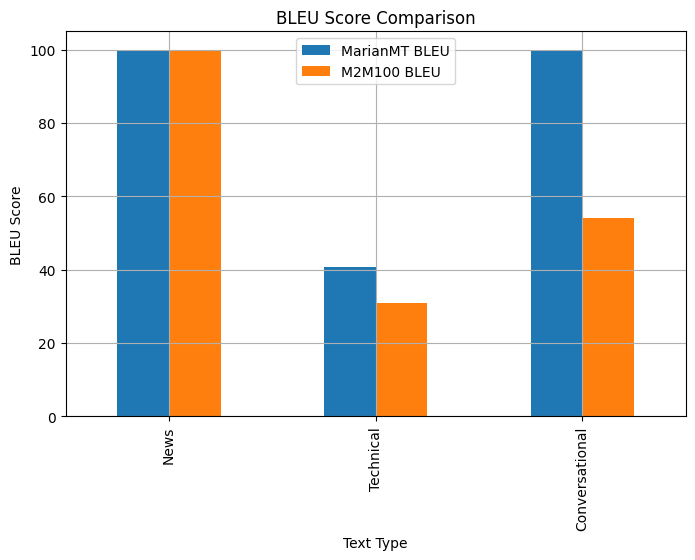

In [16]:
bleu_df.plot(
    x="Text Type",
    y=["MarianMT BLEU","M2M100 BLEU"],
    kind="bar",
    figsize=(8,5)
)

plt.title("BLEU Score Comparison")
plt.ylabel("BLEU Score")
plt.grid(True)

plt.show()

In [17]:
comparison = pd.DataFrame({

"Metric":[
"Translation Quality",
"Translation Speed",
"Memory Usage",
"CPU Usage",
"GPU Usage",
"Long Sentence Handling",
"Multilingual Support"
],

"MarianMT":[
"High",
"Fast",
"Low",
"Moderate",
"Low",
"Moderate",
"Pair-specific"
],

"M2M100":[
"High",
"Slower",
"Higher",
"Higher",
"Higher",
"Better",
"100+ Languages"
]

})

comparison

,Metric,MarianMT,M2M100
0,Translation Quality,High,High
1,Translation Speed,Fast,Slower
2,Memory Usage,Low,Higher
3,CPU Usage,Moderate,Higher
4,GPU Usage,Low,Higher
5,Long Sentence Handling,Moderate,Better
6,Multilingual Support,Pair-specific,100+ Languages


In [19]:
!pip install -q gradio

import gradio as gr

def translate_app(text, src_lang, tgt_lang):

    return translate_m2m(
        text,
        src_lang,
        tgt_lang
    )

demo = gr.Interface(
    fn=translate_app,
    inputs=[
        gr.Textbox(
            lines=4,
            label="Input Text"
        ),
        gr.Dropdown(
            ["en","fr","de","es","hi"],
            label="Source Language"
        ),
        gr.Dropdown(
            ["en","fr","de","es","hi"],
            label="Target Language"
        )
    ],
    outputs="text",
    title="Neural Machine Translation System"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0c941bfda5e4c59b3f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
